In [1]:
import pandas as pd
import numpy as np
import os
import math
import warnings
import pickle
import hashlib
from collections import Counter
from itertools import islice

import scipy
from scipy import stats
from scipy.stats import linregress, pearsonr, percentileofscore

import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
import shap

from tqdm.notebook import tqdm
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

from sklearn import metrics
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.model_selection import KFold, GridSearchCV, train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
from sklearn.utils import check_random_state, resample

from skopt import BayesSearchCV
from skopt.space import Real, Integer

warnings.filterwarnings("ignore")

c:\Users\eguen\miniconda3\envs\RedLat\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def permtest(x, y, statistic="mean", max_samples=5000, random_state=42):
    """
    Conducts a permutation test between two independent samples.
    Parameters
    ----------
    x : ndarray
        First set of datapoints.
    y : ndarray
        Second set of datapoints.
    statistic : str or callable, optional
        Function that takes in samples x and y and reports
        statistic of interest. By default, "mean" reports
        the difference of sample means. List of default
        options are ("mean", "median").
    max_samples : int, optional.
        Maximum number of label permutations to try.
    random_state : np.random.RandomState, int, or None.
        If specified, used to seed the random number generator to shuffle the ordering of the datapoints.
    """

    # Initialize random state and function of interest
    rs = check_random_state(random_state)
    stat_func = _get_stat_func(statistic)

    # Concatenate samples
    xy = np.concatenate((x, y))
    n_x = x.size

    # Observed statistic
    observed_stat = stat_func(x, y)

    # Set the number of permutations to compute
    n_perms = max(max_samples, 100000)  # Limit the number of permutations to a manageable number (e.g., 10000)

    # Allocate space for computed statistics
    shuffled_stats = np.empty(n_perms)

    # Print coverage
    print(f"Computing permutations...")

    # Sampling random permutations
    for i in range(n_perms):
        rs.shuffle(xy)
        x_ = xy[:n_x]
        y_ = xy[n_x:]
        shuffled_stats[i] = stat_func(x_, y_)

    # Compute a two-sided p-value. We take the smallest
    # percentile and then multiply by two.
    pval = 2 * min(
        percentileofscore(shuffled_stats, observed_stat, kind="rank") / 100,
        1 - percentileofscore(shuffled_stats, observed_stat, kind="rank") / 100
    )

    return pval

def _get_stat_func(name_or_func):
    """
    Instantiates functions that compute default statistics of interest.
    """
    # If specified function is callable
    if not isinstance(name_or_func, str):
        if callable(name_or_func):
            return name_or_func
        else:
            raise ValueError(
                "`statistic` should be a string like ('mean', 'median')"
                " or a function that takes in samples x, y and returns"
                " the statistic of interest."
            )

    # Default functions
    if name_or_func == "mean":
        return lambda x, y: np.mean(x) - np.mean(y)
    elif name_or_func == "median":
        return lambda x, y: np.median(x) - np.median(y)
    else:
        raise ValueError("Did not recognize statistic.")

In [3]:
# Define the pooled function to calculate the combined value of a specific measure
def pooled(x, y, func):
    nx = len(x)
    ny = len(y)
    return np.sqrt(((nx - 1) * func(x) ** 2 + (ny - 1) * func(y) ** 2) / (nx + ny - 2))

# Define the median, using the median of quantiles
def hdmedian(x):
    return np.median(x)

# Define the hdmad function to calculate the adjusted MAD (Median Absolute Deviation)
def hdmad(x):
    return 1.4826 * hdmedian(np.abs(x - hdmedian(x)))

# Calculate the pooled MAD between two datasets x and y
def phdmad(x, y):
    return pooled(x, y, hdmad)

# Define the gammaEffectSize function to calculate the gamma effect size
def gamma_effect_size(x, y, prob):
    hdquantile_x = np.percentile(x, prob * 100)
    hdquantile_y = np.percentile(y, prob * 100)
    return (hdquantile_y - hdquantile_x) / phdmad(x, y)

# Usage example
x = np.array([1, 2, 3, 4, 5])
y = np.array([3, 4, 5, 6, 7])

# Calculate the gamma effect size
prob = 0.5  # median
gamma_effect = gamma_effect_size(x, y, prob)
print(f'Gamma effect size: {gamma_effect}')

Gamma effect size: 1.3489815189531904


In [4]:
def mean_directional_accuracy(y_true, y_pred):
    
    differences = np.array(y_pred) - np.array(y_true) 
    signs = np.sign(differences)
    mde = np.mean(signs)
    return mde

def mean_absolute_error(y_true, y_pred):

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    absolute_errors = np.abs(y_pred - y_true)
    mae = np.mean(absolute_errors)
    
    return mae

In [5]:
def Regression_GBR_nested(X, y, outer_splits=10, inner_splits=5, shaps_comp=False):
    warnings.filterwarnings("ignore")

    scaler = MinMaxScaler((0.05, 0.95))

    outer_cv = KFold(n_splits=outer_splits, shuffle=True, random_state=42)
    param_grid = {
        'n_estimators': Integer(50, 500),          # Number of trees
        'learning_rate': Real(0.01, 0.5, prior='log-uniform'),  # Learning rate
        'max_depth': Integer(1, 5),               # Maximum depth of the trees
        'min_samples_split': Integer(2, 10),       # Minimum samples to split a node
        'min_samples_leaf': Integer(1, 10),        # Minimum samples in a leaf
    }

    y_labels = []
    y_predicts = []
    r_squared_l = []
    mse_l = []
    rmse_l = []

    results_labels_df = pd.DataFrame(columns=['y_labels', 'y_pred', 'GAP', 'GAP_corrected', 'ID'])

    coef_array = np.zeros([X.shape[1] + 1, outer_splits])
    lista_vars = list(X.columns)

    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X)):

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        print(f"Fold: {fold}")
        
        scaling_data = scaler.fit_transform(X_train)
        X_train = pd.DataFrame(scaling_data, columns= X_train.columns, index = X_train.index)

        scaling_data = scaler.transform(X_test)
        X_test = pd.DataFrame(scaling_data, columns= X_test.columns, index = X_test.index)
        
        model = GradientBoostingRegressor(random_state=42)
        inner_cv = KFold(n_splits=inner_splits, shuffle=True, random_state=42)
        
        bayes_search = BayesSearchCV(
            estimator=model,
            search_spaces=param_grid,
            n_iter=3,              
            scoring='r2',  
            cv=inner_cv,                   
            n_jobs=-1,             
            random_state=42
        )
        bayes_search.fit(X_train, y_train)

        best_model = bayes_search.best_estimator_

        y_pred = best_model.predict(X_test)
        gap_test = y_pred - y_test
        gap_train = best_model.predict(X_train) - y_train

        slope, intercept, _, _, _ = linregress(y_train, gap_train)
        corrected_gap = gap_test - (slope * y_test + intercept)

        result = np.column_stack((y_test, y_pred, gap_test, corrected_gap))
        temp_df = pd.DataFrame(result, columns=['y_labels', 'y_pred', 'GAP', 'GAP_corrected'])
        temp_df['ID'] = X_test.index
        results_labels_df = pd.concat([results_labels_df, temp_df], ignore_index=True)

        y_labels.extend(y_test)
        y_predicts.extend(y_pred)

        r_squared_l.append(r2_score(y_test, y_pred))
        mse_l.append(mean_squared_error(y_test, y_pred))
        rmse_l.append(math.sqrt(mse_l[-1]))

        coef_array[0, fold] = np.nan
        coef_array[1:, fold] = best_model.feature_importances_

    # Final metrics
    y_labels = np.array(y_labels)
    y_predicts = np.array(y_predicts)

    r_squared = r2_score(y_labels, y_predicts)
    r_squared_ = np.mean(r_squared_l)
    n = len(y_labels)
    p = X.shape[1]
    k = p - 1

    r_squared_adj = 1 - (1 - r_squared) * (n - 1) / (n - k - 1)
    mse = np.mean(mse_l)
    rmse = np.mean(rmse_l)
    mae = mean_absolute_error(y_labels, y_predicts)
    F = (r_squared / p) / ((1 - r_squared) / (n - p - 1))
    p_value = np.round(scipy.stats.f.sf(F, n, (n - p - 1)), 15)
    F2 = r_squared / (1 - r_squared)

    # Mean coefficients
    coef_df = pd.DataFrame(index=['_intercept'] + lista_vars,
                           columns=['Estimate mean', 'Estimate std', 't value', 'p value'])

    coef_df['Estimate mean'] = coef_array.mean(axis=1)
    coef_df['Estimate std'] = coef_array.std(axis=1)

    coef_df.loc['_intercept', 'R2'] = r_squared
    coef_df.loc['_intercept', 'R2 adj'] = r_squared_adj
    coef_df.loc['_intercept', 'R2 [+-]'] = np.std(r_squared_l)
    coef_df.loc['_intercept', 'F2'] = F2
    coef_df.loc['_intercept', 'mse'] = mse
    coef_df.loc['_intercept', 'mse [+-]'] = np.std(mse_l)
    coef_df.loc['_intercept', 'rmse'] = rmse
    coef_df.loc['_intercept', 'rmse [+-]'] = np.std(rmse_l)
    coef_df.loc['_intercept', 'outcome var'] = np.var(y)
    coef_df.loc['_intercept', 'F'] = F
    coef_df.loc['_intercept', 'F-p_value'] = p_value
    coef_df.loc['_intercept', 'MDE'] = mean_directional_accuracy(y_labels, y_predicts)
    coef_df.loc['_intercept', 'MAE'] = mae

    results_labels_df['y_pred_corrected'] = results_labels_df['y_labels'] + results_labels_df['GAP_corrected']
    results_labels_df = results_labels_df[['ID','y_labels', 'y_pred', 'GAP', 'GAP_corrected', 'y_pred_corrected']]

    if shaps_comp:
        explainer = shap.Explainer(best_model, X)
        return [coef_df, r_squared_, results_labels_df, explainer, outer_cv.split(X)]
    else:
        return [coef_df, r_squared_, results_labels_df, outer_cv.split(X)]

In [6]:
def Regression_GBR_nested(X, y, dsmcase, outer_splits=10, inner_splits=5, shaps_comp=False, control_value=1):
    """
    Nested-CV for GBR. GAP-correction is fit ONLY on training controls (dsmcase==control_value)
    and then applied to the test fold.
    X: DataFrame (features)
    y: Series (target)
    dsmcase: Series aligned with X/y; 1=controls by default (set control_value otherwise)
    """
    warnings.filterwarnings("ignore")

    # --- Scaler ---
    scaler = MinMaxScaler((0.05, 0.95))

    # --- CV and search space ---
    outer_cv = KFold(n_splits=outer_splits, shuffle=True, random_state=42)
    param_grid = {
        'n_estimators': Integer(50, 500),
        'learning_rate': Real(0.01, 0.5, prior='log-uniform'),
        'max_depth': Integer(1, 5),
        'min_samples_split': Integer(2, 10),
        'min_samples_leaf': Integer(1, 10),
    }

    # --- Collectors ---
    y_labels = []
    y_predicts = []
    r_squared_l, mse_l, rmse_l = [], [], []
    results_labels_df = pd.DataFrame(columns=['y_labels', 'y_pred', 'GAP', 'GAP_corrected', 'ID'])

    coef_array = np.zeros([X.shape[1] + 1, outer_splits])
    lista_vars = list(X.columns)

    # --- Outer CV ---
    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X)):
        print(f"Fold: {fold}")

        # Split
        X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
        y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()
        dsm_train, dsm_test = dsmcase.iloc[train_idx].copy(), dsmcase.iloc[test_idx].copy()

        # Scale
        X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
        X_test  = pd.DataFrame(scaler.transform(X_test),   columns=X_test.columns,   index=X_test.index)

        # Model + inner CV (BayesSearch)
        model = GradientBoostingRegressor(random_state=42)
        inner_cv = KFold(n_splits=inner_splits, shuffle=True, random_state=42)

        bayes_search = BayesSearchCV(
            estimator=model,
            search_spaces=param_grid,
            n_iter=3,
            scoring='r2',
            cv=inner_cv,
            n_jobs=-1,
            random_state=42
        )
        bayes_search.fit(X_train, y_train)
        best_model = bayes_search.best_estimator_

        # Predictions
        y_pred_test  = best_model.predict(X_test)
        y_pred_train = best_model.predict(X_train)

        gap_test  = y_pred_test  - y_test
        gap_train = y_pred_train - y_train

        # ----- GAP correction trained ONLY on training CONTROLS -----
        # mask of controls in train
        mask_ctrl_train = (dsm_train == control_value)
        y_train_ctrl   = y_train[mask_ctrl_train]
        gap_train_ctrl = gap_train[mask_ctrl_train]

        # Guard against too-few controls or degenerate variance
        slope, intercept = 0.0, 0.0
        y_ctrl_vals = np.asarray(y_train_ctrl, dtype=float)
        gap_ctrl_vals = np.asarray(gap_train_ctrl, dtype=float)

        # Need at least 2 points and non-zero variance in y to fit a line
        if np.sum(~np.isnan(y_ctrl_vals) & ~np.isnan(gap_ctrl_vals)) >= 2 and np.nanstd(y_ctrl_vals) > 0:
            slope, intercept, _, _, _ = linregress(y_ctrl_vals, gap_ctrl_vals)
        else:
            # Fallback: remove constant bias using mean gap on controls
            if np.isfinite(np.nanmean(gap_ctrl_vals)):
                intercept = float(np.nanmean(gap_ctrl_vals))
            else:
                intercept = 0.0
            slope = 0.0

        # Apply correction to TEST fold
        corrected_gap = gap_test - (slope * y_test + intercept)

        # Save per-sample results
        tmp = pd.DataFrame({
            'y_labels': y_test.values,
            'y_pred':   y_pred_test,
            'GAP':      gap_test,
            'GAP_corrected': corrected_gap
        }, index=y_test.index)
        tmp['ID'] = X_test.index
        results_labels_df = pd.concat([results_labels_df, tmp.reset_index(drop=True)], ignore_index=True)

        # Metrics per fold
        y_labels.extend(y_test.values)
        y_predicts.extend(y_pred_test)
        r_squared_l.append(r2_score(y_test, y_pred_test))
        mse_l.append(mean_squared_error(y_test, y_pred_test))
        rmse_l.append(math.sqrt(mse_l[-1]))

        # Feature importances (GBR)
        coef_array[0, fold] = np.nan
        coef_array[1:, fold] = best_model.feature_importances_

    # --- Aggregate metrics (across all test folds) ---
    y_labels = np.array(y_labels)
    y_predicts = np.array(y_predicts)

    r_squared = r2_score(y_labels, y_predicts)
    r_squared_mean = float(np.mean(r_squared_l))
    n = len(y_labels)
    p = X.shape[1]  # number of predictors (no intercept in X)

    # Adjusted R^2 with df = n - p - 1
    r_squared_adj = 1 - (1 - r_squared) * (n - 1) / max(1, (n - p - 1))

    mse  = float(np.mean(mse_l))
    rmse = float(np.mean(rmse_l))
    mae  = float(mean_absolute_error(y_labels, y_predicts))

    # Simple F-stat approximation (same df as OLS)
    if (n - p - 1) > 0 and (1 - r_squared) > 0 and p > 0:
        F  = (r_squared / p) / ((1 - r_squared) / (n - p - 1))
        p_value = float(np.round(stats.f.sf(F, p, (n - p - 1)), 15))
        F2 = r_squared / (1 - r_squared)
    else:
        F, p_value, F2 = np.nan, np.nan, np.nan

    # --- Coefficients/Importances summary ---
    coef_df = pd.DataFrame(index=['_intercept'] + lista_vars,
                           columns=['Estimate mean', 'Estimate std', 't value', 'p value'])

    coef_df['Estimate mean'] = coef_array.mean(axis=1)
    coef_df['Estimate std']  = coef_array.std(axis=1)

    # Global metrics in the intercept row
    coef_df.loc['_intercept', 'R2']        = r_squared
    coef_df.loc['_intercept', 'R2 adj']    = r_squared_adj
    coef_df.loc['_intercept', 'R2 [+-]']   = np.std(r_squared_l)
    coef_df.loc['_intercept', 'F2']        = F2
    coef_df.loc['_intercept', 'mse']       = mse
    coef_df.loc['_intercept', 'mse [+-]']  = np.std(mse_l)
    coef_df.loc['_intercept', 'rmse']      = rmse
    coef_df.loc['_intercept', 'rmse [+-]'] = np.std(rmse_l)
    coef_df.loc['_intercept', 'outcome var'] = np.var(y)

    coef_df.loc['_intercept', 'F']         = F
    coef_df.loc['_intercept', 'F-p_value'] = p_value

    # Optional: mean directional accuracy if your function exists
    try:
        mde = mean_directional_accuracy(y_labels, y_predicts)
    except NameError:
        mde = np.nan
    coef_df.loc['_intercept', 'MDE'] = mde
    coef_df.loc['_intercept', 'MAE'] = mae

    # Add corrected predictions (y_pred_corrected = y + GAP_corrected)
    results_labels_df['y_pred_corrected'] = results_labels_df['y_labels'] + results_labels_df['GAP_corrected']
    results_labels_df = results_labels_df[['ID','y_labels','y_pred','GAP','GAP_corrected','y_pred_corrected']]

    if shaps_comp:
        explainer = shap.Explainer(best_model, X)
        return [coef_df, r_squared_mean, results_labels_df, explainer, outer_cv.split(X)]
    else:
        return [coef_df, r_squared_mean, results_labels_df, outer_cv.split(X)]

## Functions

In [7]:
def get_best_features_sfs(data, vars_list, target_col="Age",
                          pkl_path="best_features_w-Barthel-Cognition_v01.pkl",
                          force=True):
    if (not force) and os.path.exists(pkl_path):
        with open(pkl_path, "rb") as f:
            best_features = pickle.load(f)
        print("Loaded best_features from pickle:", best_features)
    else:

        gbr = HistGradientBoostingRegressor()

        # Apply forward SFS using R2 as metric
        sfs = SFS(gbr,
                  k_features='best',  # or a fixed number like 5 or 10 if preferred
                  forward=True,
                  floating=False,
                  scoring='r2',
                  cv=5,
                  n_jobs=-1,
                  verbose=2)

        # Execute SFS
        sfs = sfs.fit(data[vars_list], data[target_col])

        # Get the best selected features
        best_features = list(sfs.k_feature_names_)
        with open(pkl_path, "wb") as f:
            pickle.dump(best_features, f)
        print("Computed and saved best_features:", best_features)

    return best_features

In [8]:
from sklearn.pipeline import Pipeline
def run_nested_cv_hgbr(data_, best_features,
                       y_col="Age", diag_col="anydem"):

    # Variables
    y = data_[y_col]
    X_selected = data_[best_features]  # selected variables

    # Outer CV
    kf = KFold(n_splits=10, shuffle=True, random_state=42)

    # Hyperparameters for Gradient Boosting
    param_grid = {
        "model__max_iter": [300, 400, 500, 600],
        "model__max_depth": [3, 5, 7],
        "model__learning_rate": [0.01, 0.05, 0.1]
    }

    # Results
    r2_scores = []
    r2_adj_scores = []  # new
    y_true_all = []
    y_pred_all = []
    results_labels_df = pd.DataFrame(columns=['y_labels', 'y_pred', 'GAP', 'GAP_corrected', 'ID'])

    # SHAP accumulator
    shap_values_sum = pd.Series(0, index=X_selected.columns)
    perm_values_sum = pd.Series(0, index=X_selected.columns)

    p = X_selected.shape[1]  # number of predictors (constant)

    # Nested CV
    for fold, (train_idx, test_idx) in enumerate(kf.split(X_selected)):
        print(f" Fold {fold + 1} (Nested CV)")

        X_train, X_test = X_selected.iloc[train_idx], X_selected.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # Pipeline
        pipeline = Pipeline([
            ("scaler", MinMaxScaler((0.05, 0.95))),
            ("model", HistGradientBoostingRegressor(random_state=42))
        ])

        # Inner GridSearch
        grid_search = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grid,
            scoring="r2",
            cv=5,
            n_jobs=-1,
            verbose=0
        )

        grid_search.fit(X_train, y_train)
        best_model = grid_search.best_estimator_

        # Evaluate
        y_pred = best_model.predict(X_test)
        r2 = r2_score(y_test, y_pred)
        r2_scores.append(r2)

        # Adjusted R2 per fold
        n_test = len(y_test)
        if (n_test - p - 1) > 0:
            r2_adj = 1 - (1 - r2) * (n_test - 1) / (n_test - p - 1)
        else:
            r2_adj = np.nan
        r2_adj_scores.append(r2_adj)

        print(f" R2 fold {fold + 1}: {r2:.4f} | R2 adj: {r2_adj:.4f} (best hyperparameters: {grid_search.best_params_})")

        y_true_all.extend(y_test)
        y_pred_all.extend(y_pred)

        # GAP
        gap_test = y_pred - y_test
        gap_train_all = best_model.predict(X_train) - y_train

        # Filter only CN subjects in train for regression
        train_ids = X_train.index
        diag_train = data_.loc[train_ids, diag_col]
        cn_mask = diag_train == 0

        slope, intercept, _, _, _ = linregress(y_train[cn_mask], gap_train_all[cn_mask])
        corrected_gap = gap_test - (slope * y_test + intercept)

        # SHAP values for this fold
        explainer = shap.Explainer(best_model.named_steps['model'], X_train)
        shap_values = explainer(X_test, check_additivity=False)
        shap_values_mean = np.abs(shap_values.values).mean(axis=0)
        shap_values_sum += pd.Series(shap_values_mean, index=X_selected.columns)

        perm_importance = permutation_importance(
            best_model, X_test, y_test, n_repeats=30, random_state=42, n_jobs=-1
        )

        # Average of the decrease in R2
        perm_values_mean = perm_importance.importances_mean
        perm_values_sum += pd.Series(perm_values_mean, index=X_selected.columns)

        # Save results for this fold
        result = np.column_stack((y_test, y_pred, gap_test, corrected_gap))
        temp_df = pd.DataFrame(result, columns=['y_labels', 'y_pred', 'GAP', 'GAP_corrected'])
        temp_df['ID'] = X_test.index
        results_labels_df = pd.concat([results_labels_df, temp_df], ignore_index=True)

    # r (Pearson correlation)
    r = np.corrcoef(y_true_all, y_pred_all)[0, 1]

    # RMSE
    rmse = np.sqrt(mean_squared_error(y_true_all, y_pred_all))

    # MAE
    mae = mean_absolute_error(y_true_all, y_pred_all)

    # Cohen's f2: f2 = R2 / (1 - R2)
    f2 = r2 / (1 - r2) if r2 < 1 else np.inf

    # Global R2 and global adjusted R2
    r2_global = r2_score(y_true_all, y_pred_all)
    n_global = len(y_true_all)
    if (n_global - p - 1) > 0:
        r2_adj_global = 1 - (1 - r2_global) * (n_global - 1) / (n_global - p - 1)
    else:
        r2_adj_global = np.nan

    # Final results
    print("\n R2 per fold (Nested CV):", r2_scores)
    print(" R2 adjusted per fold (Nested CV):", r2_adj_scores)
    print(" Average R2:", np.mean(r2_scores), np.std(r2_scores))
    print(" Average adjusted R2:", np.nanmean(r2_adj_scores), np.nanstd(r2_adj_scores))
    print(" Global R2 (all predictions):", r2_global)
    print(" Global adjusted R2:", r2_adj_global)

    print(" Cohen's f2:", f2)
    print(" r (correlation):", r)
    print(" RMSE:", rmse)
    print(" MAE:", mae)

    # Average SHAP importance
    shap_importance_avg = shap_values_sum / kf.get_n_splits()
    shap_importance_avg = shap_importance_avg.sort_values(ascending=False)
    print("\n Average SHAP values importance:")
    print(shap_importance_avg)

    # Average permutation importance
    perm_importance_avg = perm_values_sum / kf.get_n_splits()
    perm_importance_avg = perm_importance_avg.sort_values(ascending=False)
    print("\n Average importance (Permutation Importance):")
    print(perm_importance_avg)

    return (r2_scores, r2_adj_scores, results_labels_df, shap_importance_avg, perm_importance_avg, r2_global, r2_adj_global)

In [9]:
def nested_cv_flag_bad_subjects(data_, best_features, y_col="Age", diag_col="anydem"):

    # Variables
    y = data_[y_col]
    X_selected = data_[best_features]

    kf = KFold(n_splits=10, shuffle=True, random_state=42)

    param_grid = {
        "model__max_iter": [50, 100, 200],
        "model__max_depth": [3, 5, 7],
        "model__learning_rate": [0.01, 0.05, 0.1]
    }

    r2_scores = []
    y_true_all, y_pred_all = [], []
    results_labels_df = pd.DataFrame(columns=['y_labels', 'y_pred', 'GAP', 'GAP_corrected', 'ID'])
    suspected_bad_subjects = []

    # Nested CV
    for fold, (train_idx, test_idx) in enumerate(kf.split(X_selected)):
        print(f" Fold {fold + 1} (Nested CV)")

        X_train, X_test = X_selected.iloc[train_idx], X_selected.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        pipeline = Pipeline([
            ("scaler", MinMaxScaler((0.05, 0.95))),
            ("model", HistGradientBoostingRegressor(random_state=42))
        ])

        grid_search = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grid,
            scoring="r2",
            cv=5,
            n_jobs=-1,
            verbose=0
        )

        grid_search.fit(X_train, y_train)
        best_model = grid_search.best_estimator_

        y_pred = best_model.predict(X_test)
        r2 = r2_score(y_test, y_pred)
        r2_scores.append(r2)

        print(f" R2 fold {fold + 1}: {r2:.4f}")

        y_true_all.extend(y_test)
        y_pred_all.extend(y_pred)

        gap_test = y_pred - y_test
        gap_train = best_model.predict(X_train) - y_train
        slope, intercept, _, _, _ = linregress(y_train, gap_train)
        corrected_gap = gap_test - (slope * y_test + intercept)

        result = np.column_stack((y_test, y_pred, gap_test, corrected_gap))
        temp_df = pd.DataFrame(result, columns=['y_labels', 'y_pred', 'GAP', 'GAP_corrected'])
        temp_df['ID'] = X_test.index

        results_labels_df = pd.concat([results_labels_df, temp_df], ignore_index=True)

        # Identify subjects that greatly reduce R2 in this fold
        if r2 < 0.25:
            individual_errors = np.abs(y_test - y_pred)
            threshold = np.percentile(individual_errors, 95)  # top 5% worst
            bad_subjects_fold = X_test.index[individual_errors >= threshold].tolist()
            suspected_bad_subjects.extend(bad_subjects_fold)

    # Filter only those that are NOT CN
    non_cn_bad_subjects = [
        subj for subj in set(suspected_bad_subjects)
        if data_.loc[subj, diag_col] != 0
    ]

    print(f" Identified subjects (NOT CN) with negative impact: {len(non_cn_bad_subjects)}")

    # Create new dataframe without those NOT CN subjects
    data_filtered = data_.drop(index=non_cn_bad_subjects)
    print(f" New filtered dataframe: {data_filtered.shape}")

    # Final results
    print("\n Average R2:", np.mean(r2_scores), np.std(r2_scores))
    print(" Global R2:", r2_score(y_true_all, y_pred_all))

    return (data_filtered, non_cn_bad_subjects, r2_scores, results_labels_df)

## All vars model

### Load data

In [32]:
# data = pd.read_parquet(r'C:\Users\eguen\Documents\Githubs-Redlat\Repo-Gap\Brainlat\Data\Wave1_ModelA.parquet')
data = pd.read_parquet(r'C:\Users\eguen\Documents\Githubs-Redlat\Repo-Gap\Repositorio\Data_extracted\data_for_main_BAG_2025_12.parquet')

In [33]:
Counter(data['prfrate'])

Counter({0.0: 12210,
         1.0: 452,
         2.0: 50,
         3.0: 20,
         4.0: 3,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
         nan: 1,
      

In [34]:
data = data[data['prfrate']<=2]
data.reset_index(inplace=True, drop = True)

In [35]:
data = data[data['age']<=101]
data.reset_index(inplace=True, drop = True)

In [36]:
data = data.rename(columns={'age':'Age'})

In [37]:
data['pulse_pressure'] = data['sbp_mean'] - data['dbp_mean']


In [38]:
vars_list = ['Family_dementia_n',
           'Family_dementia_any', 'Sex_1F_2M', 'Education', 'Disability', 'Assets',
           'Ataxia', 'Bradykinesia','Hypertension_1Y_0N', 'Heart_Disease_1Y_0N', 'Vision_problems',
           'Audition_problems', 'Euro-D', 'pulse_pressure',
            'orthostatic_drop',
            'Stroke_1Y_0N', 'TIA_1Y_0N', 'Back_diseases', 'SRQ',
           'Visual hallucinations', 'Auditory hallucinations',
           'NPI distress score', 'NPI severity score', 'Medic_treated',
           'Arthritis', 'Cough',
           'Breathlessness', 'Breath_problems', 'Angina', 'Stomach_problems',
           'Faints', 'Paralysis', 'Limiting_illnesses', 'Skin_disorder', 'Pain',
            'Alcohol_1Y_0N', 'Physical_activities', 'Emotional_Disability',
           'Walk_1Y_0N', 'Exercise_increase', 'Medic_visits', 'Medications_1Y_0N']

In [39]:
missing_percentages = data[vars_list].isna().mean()

vars_list_clean = missing_percentages[missing_percentages <= 0.10].index.tolist()

print("Kept variables (<= 10% NaN):")
print(vars_list_clean)

print("\nRemoved variables (> 10% NaN):")
print(missing_percentages[missing_percentages > 0.10].index.tolist())

Kept variables (<= 10% NaN):
['Family_dementia_any', 'Sex_1F_2M', 'Education', 'Disability', 'Assets', 'Ataxia', 'Bradykinesia', 'Hypertension_1Y_0N', 'Heart_Disease_1Y_0N', 'Vision_problems', 'Audition_problems', 'Euro-D', 'pulse_pressure', 'orthostatic_drop', 'Stroke_1Y_0N', 'TIA_1Y_0N', 'Back_diseases', 'SRQ', 'NPI distress score', 'NPI severity score', 'Arthritis', 'Cough', 'Breathlessness', 'Breath_problems', 'Angina', 'Stomach_problems', 'Faints', 'Paralysis', 'Limiting_illnesses', 'Skin_disorder', 'Pain', 'Physical_activities', 'Emotional_Disability', 'Walk_1Y_0N', 'Exercise_increase', 'Medic_visits', 'Medications_1Y_0N']

Removed variables (> 10% NaN):
['Family_dementia_n', 'Visual hallucinations', 'Auditory hallucinations', 'Medic_treated', 'Alcohol_1Y_0N']


In [40]:
vars_list = vars_list_clean
data[vars_list] = data[vars_list].apply(lambda x: x.fillna(x.mean()))

In [42]:
data.dropna(subset=vars_list + ['Age'], inplace=True)
data.reset_index(inplace=True, drop = True)

In [43]:
Counter(data.Countries)

Counter({'Cuba': 2923,
         'Puerto Rico': 1992,
         'DR': 1982,
         'Venezuela': 1877,
         'Peru (urban)': 1373,
         'Mexico (urban)': 999,
         'Mexico (rural)': 998,
         'Peru (rural)': 549})

In [44]:
data.shape

(12693, 86)

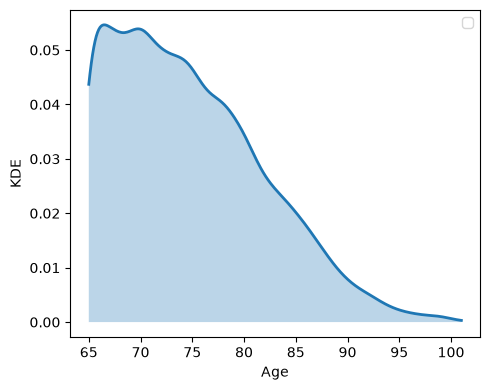

In [45]:
from scipy.stats import gaussian_kde

original_ages = data['Age'].astype(float).dropna()

# Density estimation
kde_orig = gaussian_kde(original_ages)

# Common range for comparison
x_vals = np.linspace(
    min(original_ages.min(), original_ages.min()),
    max(original_ages.max(), original_ages.max()),
    300
)

# Plot
plt.figure(figsize=(5, 4))
plt.plot(x_vals, kde_orig(x_vals), linewidth=2)
plt.fill_between(x_vals, kde_orig(x_vals), alpha=0.3)
plt.xlabel('Age')
plt.ylabel('KDE')

plt.legend()

plt.tight_layout()
plt.show()


===== Family_dementia_any =====
count    12693.000000
mean         0.105097
std          0.306691
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: Family_dementia_any, dtype: float64
Missing values: 0
Unique values (2): [np.int32(0), np.int32(1)]


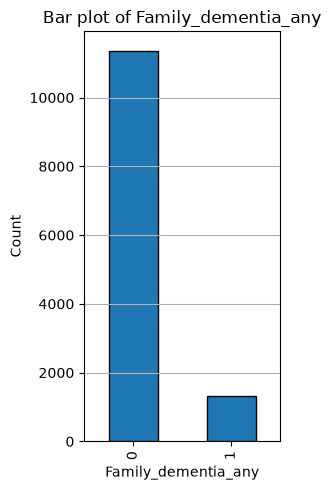


===== Sex_1F_2M =====
count    12693.000000
mean         1.355972
std          0.478807
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          2.000000
Name: Sex_1F_2M, dtype: float64
Missing values: 0
Unique values (3): [np.float64(1.0), np.float64(1.3559722659943272), np.float64(2.0)]


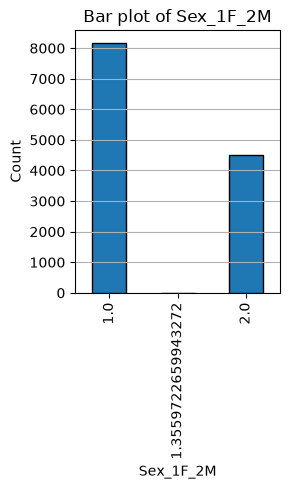


===== Education =====
count    12693.000000
mean         1.936547
std          1.169527
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          4.000000
Name: Education, dtype: float64
Missing values: 0
Unique values (6): [np.float64(0.0), np.float64(1.0), np.float64(1.936546819438957), np.float64(2.0), np.float64(3.0), np.float64(4.0)]


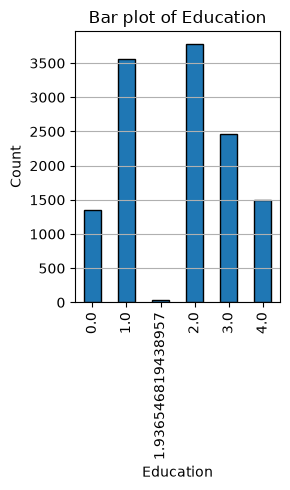


===== Disability =====
count    12693.000000
mean        13.287812
std         19.599742
min          0.000000
25%          0.000000
50%          5.555556
75%         19.444444
max        100.000000
Name: Disability, dtype: float64
Missing values: 0


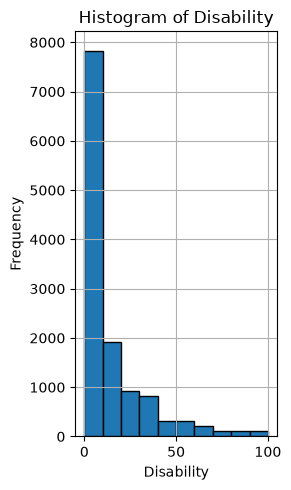


===== Assets =====
count    12693.000000
mean         5.714691
std          1.314277
min          0.000000
25%          5.000000
50%          6.000000
75%          7.000000
max          7.000000
Name: Assets, dtype: float64
Missing values: 0
Unique values (9): [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(5.71469104665826), np.float64(6.0), np.float64(7.0)]


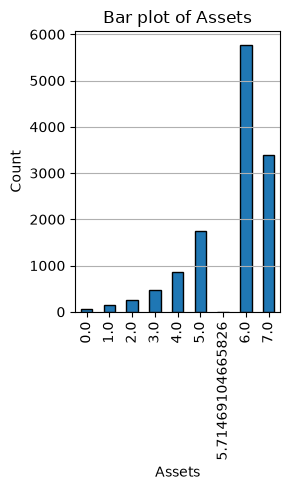


===== Ataxia =====
count    12693.000000
mean         0.168983
std          0.405904
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          2.000000
Name: Ataxia, dtype: float64
Missing values: 0
Unique values (4): [np.float64(0.0), np.float64(0.16898267284268315), np.float64(1.0), np.float64(2.0)]


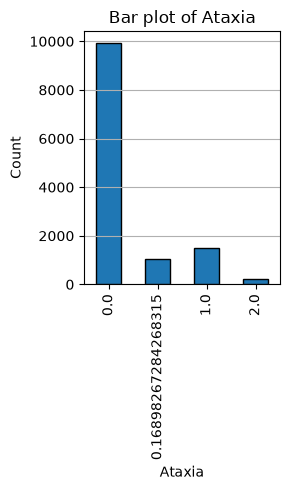


===== Bradykinesia =====
count    12693.000000
mean         0.218032
std          0.467619
min          0.000000
25%          0.000000
50%          0.000000
75%          0.218032
max          2.000000
Name: Bradykinesia, dtype: float64
Missing values: 0
Unique values (4): [np.float64(0.0), np.float64(0.21803222488858418), np.float64(1.0), np.float64(2.0)]


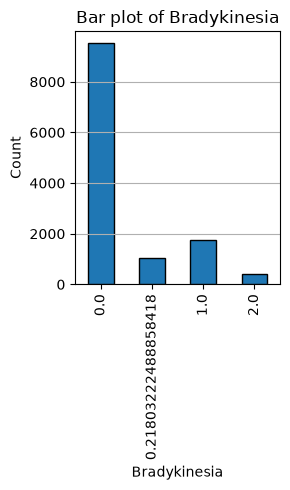


===== Hypertension_1Y_0N =====
count    12693.000000
mean         0.559044
std          0.496208
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: Hypertension_1Y_0N, dtype: float64
Missing values: 0
Unique values (3): [np.float64(0.0), np.float64(0.559043937840183), np.float64(1.0)]


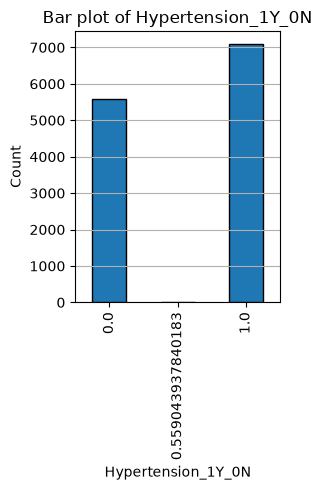


===== Heart_Disease_1Y_0N =====
count    12693.000000
mean         0.212568
std          0.408979
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: Heart_Disease_1Y_0N, dtype: float64
Missing values: 0
Unique values (3): [np.float64(0.0), np.float64(0.21256800441535914), np.float64(1.0)]


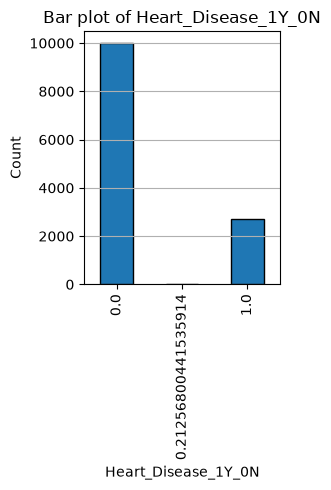


===== Vision_problems =====
count    12693.000000
mean         1.193721
std          0.902522
min          0.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          3.000000
Name: Vision_problems, dtype: float64
Missing values: 0
Unique values (5): [np.float64(0.0), np.float64(1.0), np.float64(1.193721407162013), np.float64(2.0), np.float64(3.0)]


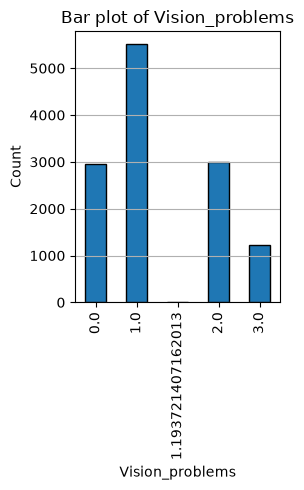


===== Audition_problems =====
count    12693.00000
mean         0.47883
std          0.83735
min          0.00000
25%          0.00000
50%          0.00000
75%          1.00000
max          3.00000
Name: Audition_problems, dtype: float64
Missing values: 0
Unique values (5): [np.float64(0.0), np.float64(0.4788299298273279), np.float64(1.0), np.float64(2.0), np.float64(3.0)]


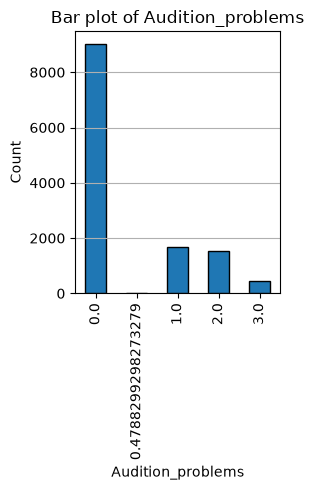


===== Euro-D =====
count    12693.000000
mean         0.272778
std          0.441245
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: Euro-D, dtype: float64
Missing values: 0
Unique values (3): [np.float64(0.0), np.float64(0.27277835754997193), np.float64(1.0)]


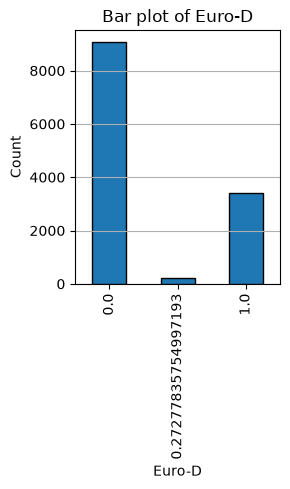


===== pulse_pressure =====
count    12693.000000
mean        56.984116
std         16.963371
min        -51.666667
25%         46.000000
50%         56.666667
75%         65.666667
max        158.666667
Name: pulse_pressure, dtype: float64
Missing values: 0


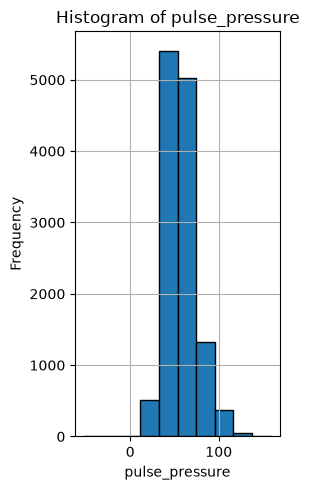


===== orthostatic_drop =====
count    12693.000000
mean         1.012493
std          0.053083
min          0.708333
25%          1.000000
50%          1.000000
75%          1.030303
max          1.955556
Name: orthostatic_drop, dtype: float64
Missing values: 0


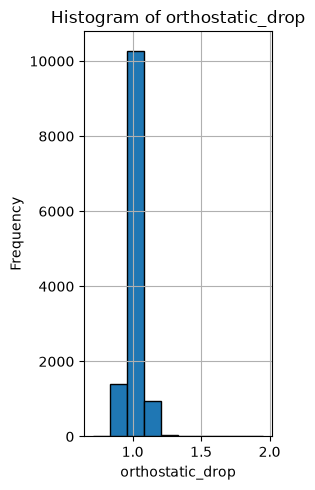


===== Stroke_1Y_0N =====
count    12693.000000
mean         0.075848
std          0.264526
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: Stroke_1Y_0N, dtype: float64
Missing values: 0
Unique values (3): [np.float64(0.0), np.float64(0.07584846093133386), np.float64(1.0)]


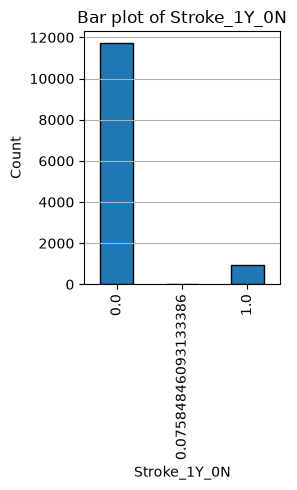


===== TIA_1Y_0N =====
count    12693.000000
mean         0.073091
std          0.259207
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: TIA_1Y_0N, dtype: float64
Missing values: 0
Unique values (3): [np.float64(0.0), np.float64(0.07309128465877493), np.float64(1.0)]


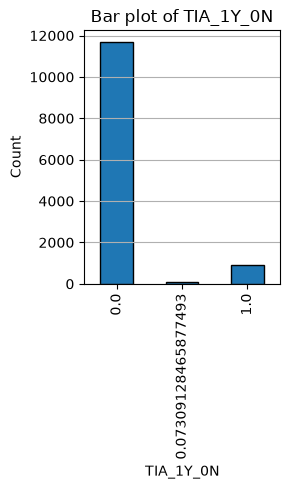


===== Back_diseases =====
count    12693.000000
mean         0.087933
std          0.200310
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.800000
Name: Back_diseases, dtype: float64
Missing values: 0
Unique values (13): [np.float64(0.0), np.float64(0.08793275545048596), np.float64(0.2), np.float64(0.25), np.float64(0.3333333333333333), np.float64(0.4), np.float64(0.5), np.float64(0.6), np.float64(0.75), np.float64(0.8), np.float64(1.0), np.float64(1.4), np.float64(1.8)]


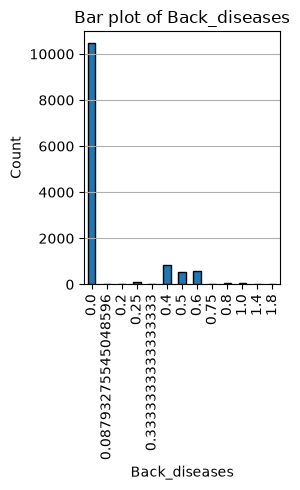


===== SRQ =====
count    12693.000000
mean         2.945157
std          3.583313
min          0.000000
25%          0.000000
50%          2.000000
75%          4.000000
max         20.000000
Name: SRQ, dtype: float64
Missing values: 0


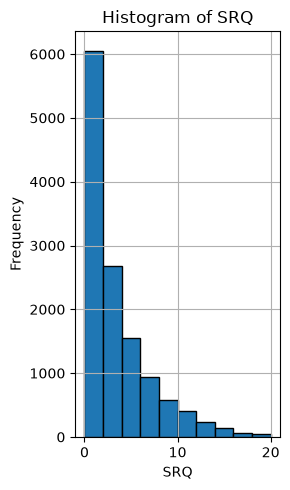


===== NPI distress score =====
count    12693.000000
mean         2.953633
std          5.079702
min          0.000000
25%          0.000000
50%          1.000000
75%          4.000000
max         52.000000
Name: NPI distress score, dtype: float64
Missing values: 0


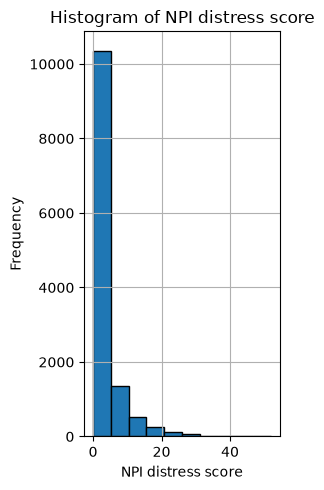


===== NPI severity score =====
count    12693.000000
mean         2.849614
std          3.998482
min          0.000000
25%          0.000000
50%          1.000000
75%          4.000000
max         36.000000
Name: NPI severity score, dtype: float64
Missing values: 0


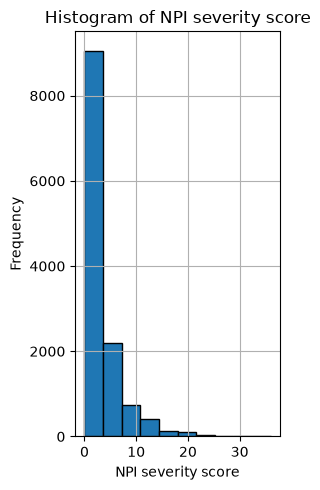


===== Arthritis =====
count    12693.000000
mean         0.777173
std          1.028567
min          0.000000
25%          0.000000
50%          0.000000
75%          2.000000
max          3.000000
Name: Arthritis, dtype: float64
Missing values: 0
Unique values (5): [np.float64(0.0), np.float64(0.7771730556870169), np.float64(1.0), np.float64(2.0), np.float64(3.0)]


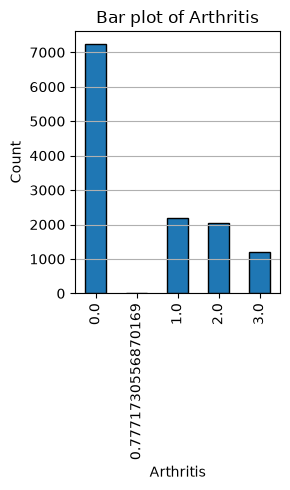


===== Cough =====
count    12693.000000
mean         0.193770
std          0.571055
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          3.000000
Name: Cough, dtype: float64
Missing values: 0
Unique values (5): [np.float64(0.0), np.float64(0.19376971608832808), np.float64(1.0), np.float64(2.0), np.float64(3.0)]


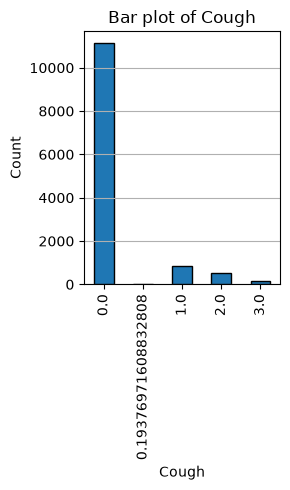


===== Breathlessness =====
count    12693.000000
mean         0.246432
std          0.644677
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          3.000000
Name: Breathlessness, dtype: float64
Missing values: 0
Unique values (5): [np.float64(0.0), np.float64(0.24643166942670136), np.float64(1.0), np.float64(2.0), np.float64(3.0)]


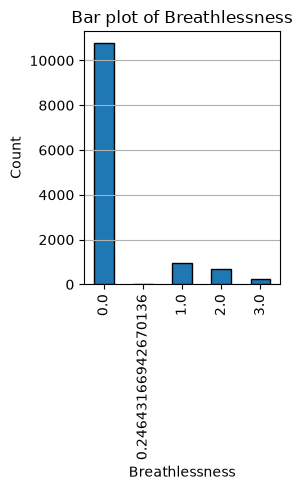


===== Breath_problems =====
count    12693.000000
mean         0.220137
std          0.490284
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          3.000000
Name: Breath_problems, dtype: float64
Missing values: 0
Unique values (8): [np.float64(0.0), np.float64(0.22013719151620278), np.float64(0.5), np.float64(1.0), np.float64(1.5), np.float64(2.0), np.float64(2.5), np.float64(3.0)]


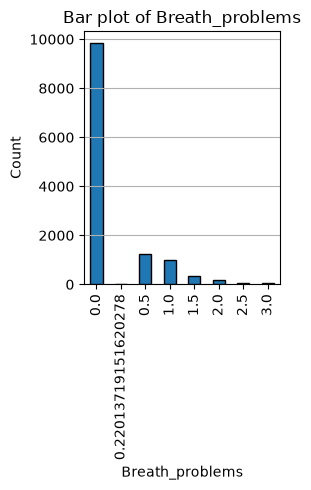


===== Angina =====
count    12693.000000
mean         0.252306
std          0.594956
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          3.000000
Name: Angina, dtype: float64
Missing values: 0
Unique values (5): [np.float64(0.0), np.float64(0.2523062366947883), np.float64(1.0), np.float64(2.0), np.float64(3.0)]


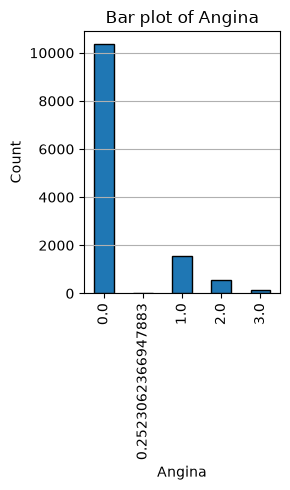


===== Stomach_problems =====
count    12693.000000
mean         0.502642
std          0.847038
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          3.000000
Name: Stomach_problems, dtype: float64
Missing values: 0
Unique values (5): [np.float64(0.0), np.float64(0.5026417474962542), np.float64(1.0), np.float64(2.0), np.float64(3.0)]


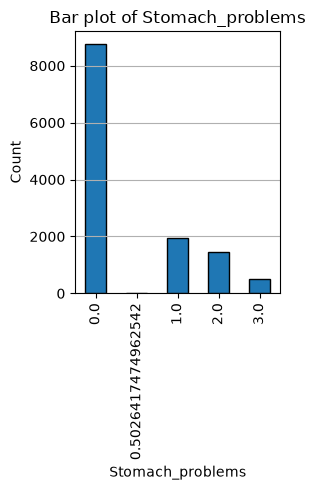


===== Faints =====
count    12693.000000
mean         0.064832
std          0.347735
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          3.000000
Name: Faints, dtype: float64
Missing values: 0
Unique values (5): [np.float64(0.0), np.float64(0.06483161132581435), np.float64(1.0), np.float64(2.0), np.float64(3.0)]


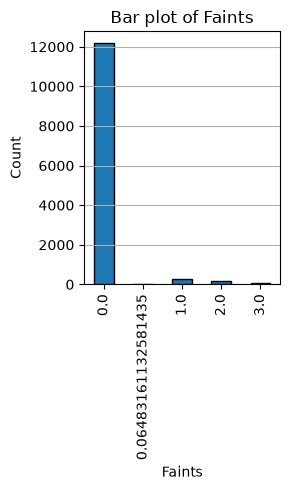


===== Paralysis =====
count    12693.000000
mean         0.143454
std          0.559989
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          3.000000
Name: Paralysis, dtype: float64
Missing values: 0
Unique values (5): [np.float64(0.0), np.float64(0.14345425867507886), np.float64(1.0), np.float64(2.0), np.float64(3.0)]


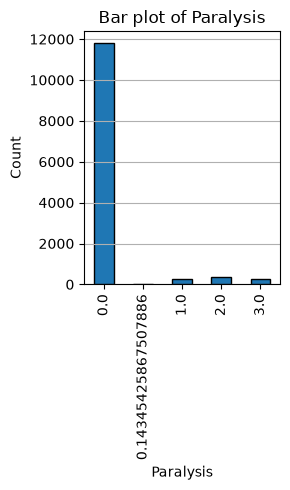


===== Limiting_illnesses =====
count    12693.000000
mean         0.782163
std          0.724861
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          2.000000
Name: Limiting_illnesses, dtype: float64
Missing values: 0
Unique values (3): [np.float64(0.0), np.float64(1.0), np.float64(2.0)]


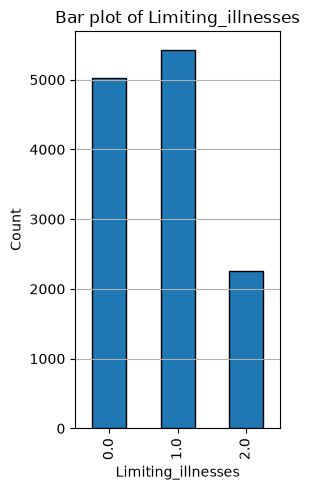


===== Skin_disorder =====
count    12693.000000
mean         0.110103
std          0.441352
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          3.000000
Name: Skin_disorder, dtype: float64
Missing values: 0
Unique values (5): [np.float64(0.0), np.float64(0.11010332045113969), np.float64(1.0), np.float64(2.0), np.float64(3.0)]


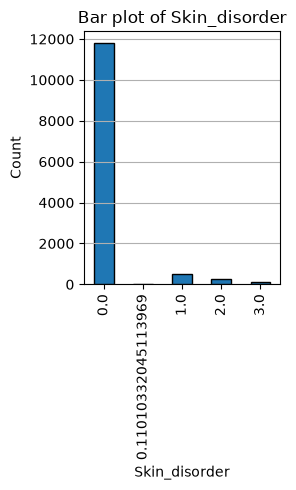


===== Pain =====
count    12693.000000
mean         1.335631
std          1.301061
min          0.333333
25%          0.333333
50%          0.333333
75%          2.333333
max          5.000000
Name: Pain, dtype: float64
Missing values: 0


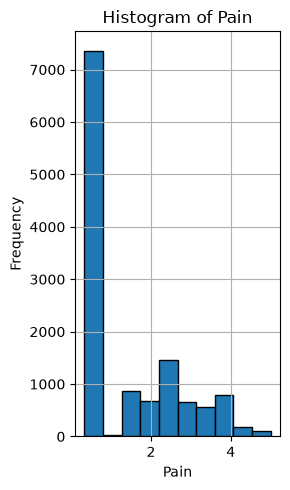


===== Physical_activities =====
count    12693.000000
mean         1.826266
std          0.887036
min          0.000000
25%          1.000000
50%          2.000000
75%          2.000000
max          3.000000
Name: Physical_activities, dtype: float64
Missing values: 0
Unique values (5): [np.float64(0.0), np.float64(1.0), np.float64(1.82626582278481), np.float64(2.0), np.float64(3.0)]


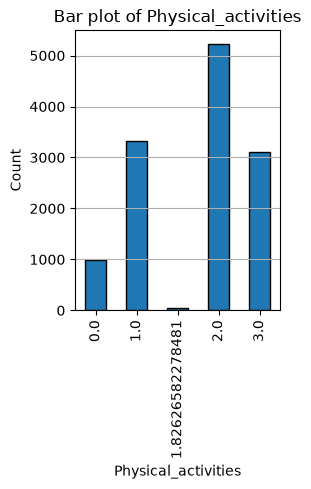


===== Emotional_Disability =====
count    12693.000000
mean         0.321632
std          0.628037
min          0.000000
25%          0.000000
50%          0.000000
75%          0.500000
max          4.000000
Name: Emotional_Disability, dtype: float64
Missing values: 0


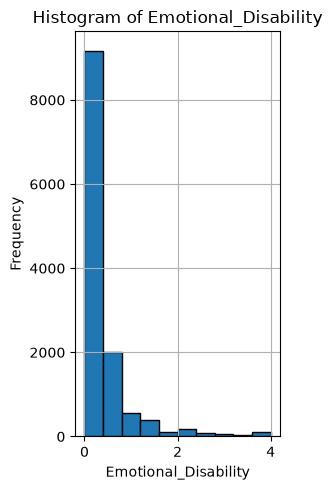


===== Walk_1Y_0N =====
count    12693.000000
mean         0.584218
std          0.491495
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: Walk_1Y_0N, dtype: float64
Missing values: 0
Unique values (3): [np.float64(0.0), np.float64(0.5842180320076058), np.float64(1.0)]


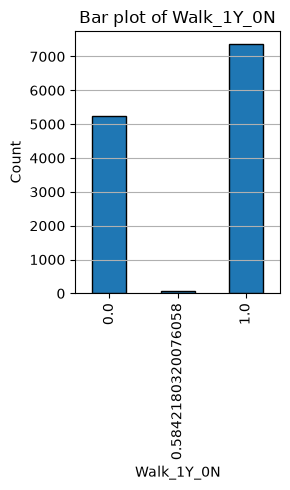


===== Exercise_increase =====
count    12693.000000
mean         1.327306
std          0.591342
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          3.000000
Name: Exercise_increase, dtype: float64
Missing values: 0
Unique values (4): [np.float64(1.0), np.float64(1.3273058926163852), np.float64(2.0), np.float64(3.0)]


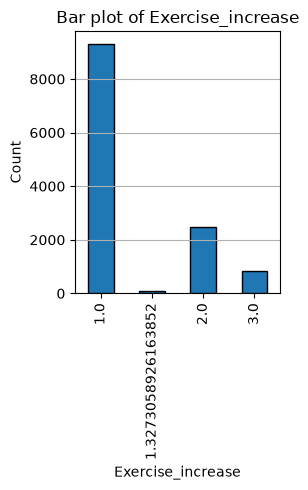


===== Medic_visits =====
count    12693.000000
mean         0.087174
std          0.143345
min          0.000000
25%          0.000000
50%          0.000000
75%          0.250000
max          0.750000
Name: Medic_visits, dtype: float64
Missing values: 0
Unique values (4): [np.float64(0.0), np.float64(0.25), np.float64(0.5), np.float64(0.75)]


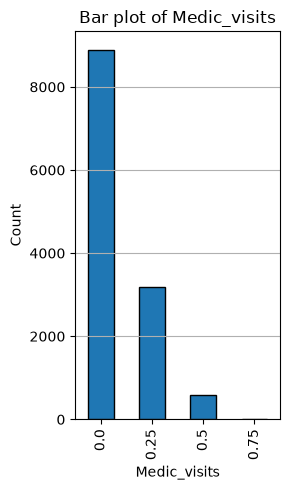


===== Medications_1Y_0N =====
count    12693.000000
mean         0.741727
std          0.437685
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: Medications_1Y_0N, dtype: float64
Missing values: 0
Unique values (3): [np.float64(0.0), np.float64(0.7417270721714466), np.float64(1.0)]


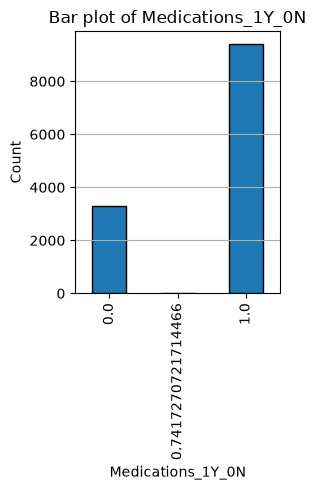

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

# List of variables to analyze


# Descriptive analysis
for var in vars_list:
    print(f"\n===== {var} =====")
    print(data[var].describe())
    print("Missing values:", data[var].isna().sum())
    
    # Get unique values
    unique_vals = data[var].dropna().unique()
    n_unique = len(unique_vals)
    
    if n_unique < 15:
        print(f"Unique values ({n_unique}): {sorted(unique_vals)}")
        
        # Bar plot for categorical variables
        value_counts = data[var].value_counts().sort_index()
        plt.figure(figsize=(3,5))
        value_counts.plot(kind='bar', edgecolor='black')
        plt.title(f'Bar plot of {var}')
        plt.xlabel(var)
        plt.ylabel('Count')
        plt.grid(True, axis='y')
        plt.tight_layout()
        plt.show()
    else:
        # Histogram for continuous variables
        plt.figure(figsize=(3,5))
        plt.hist(data[var].dropna(), bins=10, edgecolor='black')
        plt.title(f'Histogram of {var}')
        plt.xlabel(var)
        plt.ylabel('Frequency')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

### SFS all subjects

In [47]:
best_features = get_best_features_sfs(data, vars_list,
                   target_col="Age",
                   pkl_path=r"C:\Users\eguen\Documents\Githubs-Redlat\Repo-Gap\Brainlat\SFS\best_features-wo-used-diag-vars_all-subjects.pkl",
                   force=False)


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  33 out of  37 | elapsed:    8.3s remaining:    0.9s
[Parallel(n_jobs=-1)]: Done  37 out of  37 | elapsed:    8.4s finished

[2026-06-23 12:49:11] Features: 1/37 -- score: 0.08896642477743773[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  32 out of  36 | elapsed:    2.5s remaining:    0.2s
[Parallel(n_jobs=-1)]: Done  36 out of  36 | elapsed:    2.7s finished

[2026-06-23 12:49:14] Features: 2/37 -- score: 0.10867353642871636[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 out of  35 | elapsed:    2.5s remaining:    0.3s
[Parallel(n_jobs=-1)]: Done  35 out of  35 | elapsed:    2.6s finished

[2026-06-23 12:49:17] Features: 3/37 -- score: 0.1261521803667391[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  29 out 

Computed and saved best_features: ['Sex_1F_2M', 'Education', 'Disability', 'Ataxia', 'Bradykinesia', 'Hypertension_1Y_0N', 'Audition_problems', 'Euro-D', 'pulse_pressure', 'orthostatic_drop', 'NPI distress score', 'Arthritis', 'Cough', 'Breathlessness', 'Angina', 'Paralysis', 'Limiting_illnesses', 'Pain', 'Physical_activities', 'Emotional_Disability', 'Walk_1Y_0N', 'Exercise_increase', 'Medications_1Y_0N']



[2026-06-23 12:51:22] Features: 37/37 -- score: 0.19525053190717398

In [ ]:
lista1= ['Sex_1F_2M', 'Education', 'Disability', 'Ataxia', 'Bradykinesia', 'Hypertension_1Y_0N', 'Heart_Disease_1Y_0N', 'Audition_problems', 'Euro-D', 'pulse_pressure', 'Stroke_1Y_0N', 'Breath_problems', 'Stomach_problems', 'Faints', 'Paralysis', 'Limiting_illnesses', 'Skin_disorder', 'Pain', 'Physical_activities', 'Emotional_Disability', 'Walk_1Y_0N', 'Medications_1Y_0N']
lista = ['Family_dementia_any', 'Sex_1F_2M', 'Education', 'Disability', 'Assets', 'Ataxia', 'Bradykinesia', 'Hypertension_1Y_0N', 'Heart_Disease_1Y_0N', 'Vision_problems', 'Audition_problems', 'Euro-D', 'pulse_pressure', 'Stroke_1Y_0N', 'Cough', 'Breath_problems', 'Angina', 'Stomach_problems', 'Faints', 'Limiting_illnesses', 'Pain', 'Physical_activities', 'Emotional_Disability', 'Walk_1Y_0N', 'Exercise_increase', 'Medications_1Y_0N']
lista2= ['Sex_1F_2M', 'Education', 'Disability', 'Ataxia', 'Bradykinesia', 'Hypertension_1Y_0N', 'Heart_Disease_1Y_0N', 'Vision_problems', 'Audition_problems', 'Euro-D', 'pulse_pressure', 'Stroke_1Y_0N', 'TIA_1Y_0N', 'Cough', 'Breathlessness', 'Breath_problems', 'Stomach_problems', 'Pain', 'Physical_activities', 'Emotional_Disability', 'Walk_1Y_0N', 'Medications_1Y_0N']



In [52]:
## Ensure these are taken into account
best_features.append('Sex_1F_2M')
best_features.append('Education')

best_features = list(np.unique(best_features))

In [53]:
best_features

[np.str_('Angina'),
 np.str_('Arthritis'),
 np.str_('Ataxia'),
 np.str_('Audition_problems'),
 np.str_('Bradykinesia'),
 np.str_('Breathlessness'),
 np.str_('Cough'),
 np.str_('Disability'),
 np.str_('Education'),
 np.str_('Emotional_Disability'),
 np.str_('Euro-D'),
 np.str_('Exercise_increase'),
 np.str_('Hypertension_1Y_0N'),
 np.str_('Limiting_illnesses'),
 np.str_('Medications_1Y_0N'),
 np.str_('NPI distress score'),
 np.str_('Pain'),
 np.str_('Paralysis'),
 np.str_('Physical_activities'),
 np.str_('Sex_1F_2M'),
 np.str_('Walk_1Y_0N'),
 np.str_('orthostatic_drop'),
 np.str_('pulse_pressure')]

### BBAGs model-all subjects

In [ ]:
#!pip install scikit-optimize

#from scipy.stats import pointbiserialr
#
## Assuming 'Age' is continuous and 'Group' is binary 0/1
#corr, p_value = pointbiserialr(data['Diabetes_1Y_0N'], data['Age'])
#
#print(f"Point-biserial correlation: {corr:.3f}, p-value: {p_value:.3f}")

In [34]:
r2_scores, r2_adj_scores, results_df, shap_imp, perm_imp, r2_global, r2_adj_global = run_nested_cv_hgbr(
  data_=data,
  best_features=best_features,
  y_col="Age",
  diag_col="anydem"
)


🔁 Fold 1 (Nested CV)
🏆 R² fold 1: 0.2236 | R² adj: 0.2099 (mejores hiperparámetros: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__max_iter': 300})
🔁 Fold 2 (Nested CV)
🏆 R² fold 2: 0.2282 | R² adj: 0.2146 (mejores hiperparámetros: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__max_iter': 300})
🔁 Fold 3 (Nested CV)
🏆 R² fold 3: 0.2204 | R² adj: 0.2066 (mejores hiperparámetros: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__max_iter': 300})
🔁 Fold 4 (Nested CV)
🏆 R² fold 4: 0.2423 | R² adj: 0.2289 (mejores hiperparámetros: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__max_iter': 300})
🔁 Fold 5 (Nested CV)
🏆 R² fold 5: 0.2769 | R² adj: 0.2641 (mejores hiperparámetros: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__max_iter': 300})
🔁 Fold 6 (Nested CV)
🏆 R² fold 6: 0.2376 | R² adj: 0.2241 (mejores hiperparámetros: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__max_iter': 300})
🔁 Fold 7 (Nested CV)
🏆

In [49]:
data

,Countries,smoke_years,smoke_ratio,Family_dementia_n,Family_dementia_any,Sex_1F_2M,Education,Disability,Assets,Ataxia,...,mci,eurocase,anydem,cogcase,prfrate,date,particid,householdid,centreid,pulse_pressure
0,Cuba,29.0,0.402778,NaN,0,1.0,4.0,88.888889,6.0,0.000000,...,0,NaN,1.0,3,0.0,2003-09-05,1,1,1,37.333333
1,Cuba,32.0,0.415584,2.0,1,2.0,3.0,2.777778,6.0,0.000000,...,0,1.0,0.0,1,0.0,2003-10-07,2,1,1,66.333333
2,Cuba,23.0,0.353846,1.0,1,1.0,4.0,22.222222,7.0,0.000000,...,0,1.0,0.0,1,0.0,2003-09-01,1,2,1,47.666667
3,Cuba,0.0,0.000000,NaN,0,1.0,3.0,8.333333,6.0,0.000000,...,0,1.0,0.0,1,0.0,2003-09-02,1,3,1,130.000000
4,Cuba,0.0,0.000000,NaN,0,2.0,4.0,0.000000,6.0,0.000000,...,0,0.0,1.0,3,0.0,2003-09-02,2,3,1,40.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12688,Puerto Rico,0.0,0.000000,1.0,1,1.0,3.0,27.777778,7.0,1.000000,...,0,0.0,0.0,1,0.0,2009-06-23,1,10266,20,50.666667
12689,Puerto Rico,0.0,0.000000,1.0,1,1.0,4.0,0.000000,7.0,0.000000,...,0,0.0,0.0,1,0.0,2009-06-23,2,10266,20,47.333333
12690,Puerto Rico,23.0,0.277108,NaN,0,1.0,1.0,2.777778,7.0,1.000000,...,0,0.0,1.0,3,0.0,2009-06-23,1,10267,20,86.666667
12691,Puerto Rico,0.0,0.000000,NaN,0,1.0,0.0,19.444444,6.0,1.000000,...,0,0.0,1.0,3,0.0,2009-06-23,1,10268,20,88.666667


In [36]:
def make_generic_id(row):
  h = row['householdid']
  p = row['particid']
  def to_str(val):
    if pd.isna(val): return ""
    if isinstance(val, float) and val.is_integer(): return str(int(val))
    return str(val)
  if pd.isna(h) or pd.isna(p): return np.nan
  uid_str = to_str(h) + "_" + to_str(p)
  return 'SUBJ_' + hashlib.md5(uid_str.encode()).hexdigest()[:8]

if 'particid' in data.columns and 'householdid' in data.columns:
  data['uid'] = data.apply(make_generic_id, axis=1)

results_df['y_pred_corrected'] = results_df['y_labels'] + results_df['GAP_corrected']
results_df = results_df.set_index('ID')

results_df = results_df.sort_index()

df_final = pd.concat([data[['uid', 'date', 'Age', 'anydem', 'dsmcase', 'cogcase', 'mci', 'Countries'] + best_features], results_df], axis = 1)

In [37]:
df_final.to_parquet('Results/wo-used-diag-vars_all-subjects.parquet')

perm_imp.to_frame(name="perm_importance").to_parquet("Results/wo-used-diag-vars_all-subjects-perm_imp.parquet")


import pickle

out = {
  "r2_scores": r2_scores,
  "r2_adj_scores": r2_adj_scores,
  "r2_global": r2_global,
  "r2_adj_global": r2_adj_global
}

with open("Results/r2_wo-used-diag-vars_all-subjects.pkl", "wb") as f:
  pickle.dump(out, f)


### Filtering bad subjects

In [38]:
data_filtered, non_cn_bad_subjects, r2_scores, results_df = nested_cv_flag_bad_subjects(
  data_=data,
  best_features=best_features,
  y_col="Age",
  diag_col="anydem"
)


🔁 Fold 1 (Nested CV)
🏆 R² fold 1: 0.2220
🔁 Fold 2 (Nested CV)
🏆 R² fold 2: 0.2247
🔁 Fold 3 (Nested CV)
🏆 R² fold 3: 0.2197
🔁 Fold 4 (Nested CV)
🏆 R² fold 4: 0.2423
🔁 Fold 5 (Nested CV)
🏆 R² fold 5: 0.2747
🔁 Fold 6 (Nested CV)
🏆 R² fold 6: 0.2384
🔁 Fold 7 (Nested CV)
🏆 R² fold 7: 0.2700
🔁 Fold 8 (Nested CV)
🏆 R² fold 8: 0.1860
🔁 Fold 9 (Nested CV)
🏆 R² fold 9: 0.2447
🔁 Fold 10 (Nested CV)
🏆 R² fold 10: 0.2504
🚩 Sujetos identificados (NO CN) con impacto negativo: 94
✅ Nuevo dataframe filtrado: (12599, 86)

📊 R² promedio: 0.23728976892010714 0.02458541121319622
📊 R² global: 0.23814124439218765


### BBAGs model-filtered subjects (same results as all-subjects since no subject had a negative impact)

In [ ]:
r2_scores, r2_adj_scores, results_df, shap_imp, perm_imp, r2_global, r2_adj_global = run_nested_cv_hgbr(
  data_=data_filtered,
  best_features=best_features,
  y_col="Age",
  diag_col="anydem"
)

🔁 Fold 1 (Nested CV)
🏆 R² fold 1: 0.2168 | R² adj: 0.2029 (mejores hiperparámetros: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__max_iter': 300})
🔁 Fold 2 (Nested CV)
🏆 R² fold 2: 0.2526 | R² adj: 0.2393 (mejores hiperparámetros: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__max_iter': 400})
🔁 Fold 3 (Nested CV)
🏆 R² fold 3: 0.2166 | R² adj: 0.2026 (mejores hiperparámetros: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__max_iter': 300})
🔁 Fold 4 (Nested CV)
🏆 R² fold 4: 0.2384 | R² adj: 0.2248 (mejores hiperparámetros: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__max_iter': 300})
🔁 Fold 5 (Nested CV)
🏆 R² fold 5: 0.2387 | R² adj: 0.2252 (mejores hiperparámetros: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__max_iter': 300})
🔁 Fold 6 (Nested CV)
🏆 R² fold 6: 0.2653 | R² adj: 0.2522 (mejores hiperparámetros: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__max_iter': 300})
🔁 Fold 7 (Nested CV)
🏆

In [40]:
if 'particid' in data_filtered.columns and 'householdid' in data_filtered.columns:
  data_filtered['uid'] = data_filtered.apply(make_generic_id, axis=1)

results_df['y_pred_corrected'] = results_df['y_labels'] + results_df['GAP_corrected']
results_df = results_df.set_index('ID')

results_df = results_df.sort_index()

df_final = pd.concat([data_filtered[['uid', 'date', 'Age', 'anydem', 'dsmcase', 'cogcase', 'mci', 'Countries'] + best_features], results_df], axis = 1)

In [41]:
df_final.to_parquet('Results/wo-used-diag-vars_filtered-subjects.parquet')
perm_imp.to_frame(name="perm_importance").to_parquet("Results/wo-used-diag-vars_filtered-subjects-perm_imp.parquet")


out = {
  "r2_scores": r2_scores,
  "r2_adj_scores": r2_adj_scores,
  "r2_global": r2_global,
  "r2_adj_global": r2_adj_global
}

with open("Results/r2_wo-used-diag-vars_filtered-subjects.pkl", "wb") as f:
  pickle.dump(out, f)
